In [13]:
# import pandas as pd

# url_internacional = "https://github.com/Omar-Velez/bootcamp/raw/refs/heads/main/llegada_mensual_pasajeros_aeropuerto_de_origen_internacional.csv"

# url_nacional = "https://github.com/Omar-Velez/bootcamp/raw/refs/heads/main/llegada_pasajeros_mensual_por_aeropuerto_de_origen_nacional.csv"

# df_internacional = pd.read_csv(url_internacional)
# df_nacional = pd.read_csv(url_nacional)

import pandas as pd

# CARGA DE DATOS
url_internacional = 'https://github.com/juliandariogiraldoocampo/ia_taltech/raw/refs/heads/main/aeropuerto/llegada_mensual_pasajeros_aeropuerto_de_origen_internacional.csv'
url_nacional = 'https://github.com/juliandariogiraldoocampo/ia_taltech/raw/refs/heads/main/aeropuerto/llegada_pasajeros_mensual_por_aeropuerto_de_origen_nacional.csv'

df_nacional = pd.read_csv(url_nacional)
df_internacional = pd.read_csv(url_internacional)

In [ ]:
display(df_internacional.head(1))
display(df_nacional.head(1))

In [ ]:
#display(df_nacional.describe())
display(df_internacional.describe())

In [ ]:
display(df_nacional.info())
print('**********************************************')
display(df_internacional.info())

In [ ]:
#display(df_nacional.describe())
display(df_nacional.describe())

In [ ]:
df_nacional.isnull().sum()

In [6]:
# Cuáles son los 5 aeropuertos que generan mayor volumen de pasajeros?

top_5_origen_nacional = df_nacional.groupby('lle_llegadanal')['lle_valor'].sum().sort_values(ascending=False).head(5)

display(top_5_origen_nacional)
#top_5_nacional = df_nacional.groupby('Aeropuerto_Origen')['Pasajeros'].sum().sort_values(ascending=False).head(10)

lle_llegadanal
BOGOTA          20137280
CARTAGENA        4074012
CALI             3206186
SANTA MARTA      2181152
BARRANQUILLA     2171641
Name: lle_valor, dtype: int64

In [7]:
# Cuáles son los meses de mayor volumen de pasajeros?

top_meses_nacional = df_nacional.groupby('lle_periodo')['lle_valor'].sum().sort_values(ascending=False).head(5)

display(top_meses_nacional)

lle_periodo
202207    473013
202212    468364
202208    461587
202210    456188
202206    449755
Name: lle_valor, dtype: int64

In [14]:
# Crear columnas de año y mes a partir de la columna 'lle_periodo'

df_nacional['Año'] = df_nacional['lle_periodo'].astype(str).str[:4].astype(int)
df_nacional['Mes'] = df_nacional['lle_periodo'].astype(str).str[:4].astype(int)
display(df_nacional.head(5))

,lle_codigo,lle_indicador,lle_llegadanal,lle_periodo,lle_valor,Año,Mes
0,13001,LLEGADA_PAX_NACIONAL,CARTAGENA,202209,49243,2022,2022
1,17001,LLEGADA_PAX_NACIONAL,MANIZALES,202209,2220,2022,2022
2,5873,LLEGADA_PAX_NACIONAL,VIGIA DEL FUERTE,202209,125,2022,2022
3,15189,LLEGADA_PAX_NACIONAL,CIENAGA,202209,7,2022,2022
4,27077,LLEGADA_PAX_NACIONAL,BAJO BAUDO,202209,121,2022,2022


,Codigo,Indicador,Periodo,Origen,Pax,Año,Mes
0,13001,LLEGADA_PAX_NACIONAL,CARTAGENA,202209,49243,2022,2022
1,17001,LLEGADA_PAX_NACIONAL,MANIZALES,202209,2220,2022,2022
2,5873,LLEGADA_PAX_NACIONAL,VIGIA DEL FUERTE,202209,125,2022,2022
3,15189,LLEGADA_PAX_NACIONAL,CIENAGA,202209,7,2022,2022
4,27077,LLEGADA_PAX_NACIONAL,BAJO BAUDO,202209,121,2022,2022



      Total de pasajeros nacionales: 44563448
      Total de pasajeros internacionales: 10001834
      


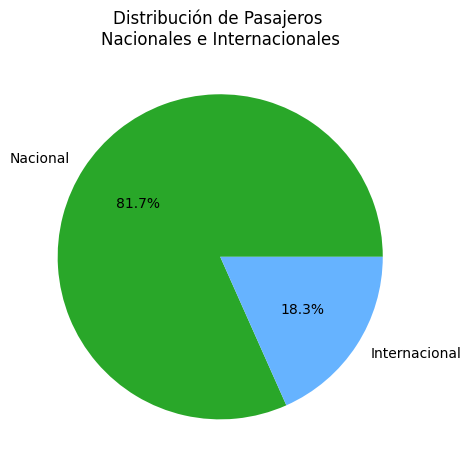

In [29]:
import matplotlib.pyplot as plt

# Renombrar columnas para mayor claridad IA
# df_nacional.rename(columns={'lle_codigo': 'Codigo', 'lle_indicador': 'Indicador', 'lle_periodo': 'Periodo','lle_llegadanal':'Origen'}, inplace=True)

# renombrar columnas mintic
df_nacional.columns = ['Codigo', 'Indicador', 'Periodo', 'Origen', 'Pax', 'Año', 'Mes']

display(df_nacional.head(5))

total_nacional = df_nacional['Pax'].sum()
total_internacional = df_internacional['lle_valor'].sum()

print(f'''
      Total de pasajeros nacionales: {total_nacional}
      Total de pasajeros internacionales: {total_internacional}
      ''')

# Crear lista de datos para graficar en tipo pie chart
data = [total_nacional, total_internacional]
labels = ['Nacional', 'Internacional']

# Visualizar la distribución de pasajeros nacionales e internacionales
plt.title('Distribución de Pasajeros \nNacionales e Internacionales')
plt.Figure(figsize=(8, 8))
# cambiar colores del pie chart
colors = ["#29a729",'#66b3ff']
plt.pie(data,colors=colors, labels=labels, autopct='%1.1f%%')
plt.tight_layout()
plt.show()  